# Campaign dynamics and observable/oracle graph investigation

**Goal.** Follow evolving fraud campaigns through state transitions, temporal graph construction, and an as-of investigator view. Compare observable evidence with oracle truth without leaking future events.

**Audience.** Data/ML scientists, fraud analysts, platform engineers, and researchers.

**Prerequisites.** Python 3.12+, a clean checkout, and the base FraudTwin install. The workflow is deterministic and runs offline; service integrations are deliberately out of scope here.

**Source size.** 1,000–10,000 logical payments. Every section writes only compact summaries, manifests, or fingerprints to a temporary directory.

**Interpretation.** Synthetic evidence demonstrates mechanics and invariants, not production prevalence or model performance guarantees.


## Campaign dynamics and evolving fraud rings



In [1]:
from collections import Counter
from pathlib import Path

from fraudtwin.config import load_config
from fraudtwin.generation import generate
from fraudtwin.reproducibility import sha256_json

root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs" / "minimal.yaml").is_file()),
    Path.cwd(),
)
config = load_config(root / "configs" / "benchmarks" / "m15-campaign-dynamics-v1.yaml")
data = generate(config, write=False)
dynamic = data.behavior.campaign_dynamics
print(
    {
        "run_id": data.run_id,
        "payments": len(data.behavior.payments),
        "campaigns": len(data.behavior.graph_campaigns),
    }
)
assert dynamic is not None and dynamic.active

{'run_id': 'RUN-b80445cbde717564', 'payments': 733, 'campaigns': 3}


In [2]:
print(
    {
        "snapshots": len(dynamic.snapshots),
        "transitions": len(dynamic.transitions),
        "phase_changes": len(dynamic.phase_changes),
        "membership_changes": len(dynamic.membership_changes),
        "intensity": len(dynamic.intensity_decisions),
    }
)
assert dynamic.snapshots and dynamic.transitions

{'snapshots': 30, 'transitions': 30, 'phase_changes': 30, 'membership_changes': 6, 'intensity': 30}


In [3]:
campaigns = [
    {"id": x.campaign_id, "scenario": x.scenario_type, "participants": len(x.participant_ids)}
    for x in data.behavior.graph_campaigns
]
print("Campaigns:")
for campaign in campaigns:
    scenario = campaign["scenario"].replace("_", " ").title()
    print(f"  {campaign['id']}: {scenario} ({campaign['participants']} participants)")
assert len(campaigns) == 3

Campaigns:
  G-MULE_NETWORK-0001: Mule Network (5 participants)
  G-CYCLIC_RING-0002: Cyclic Ring (4 participants)
  G-DENSE_CAMPAIGN-0003: Dense Campaign (4 participants)


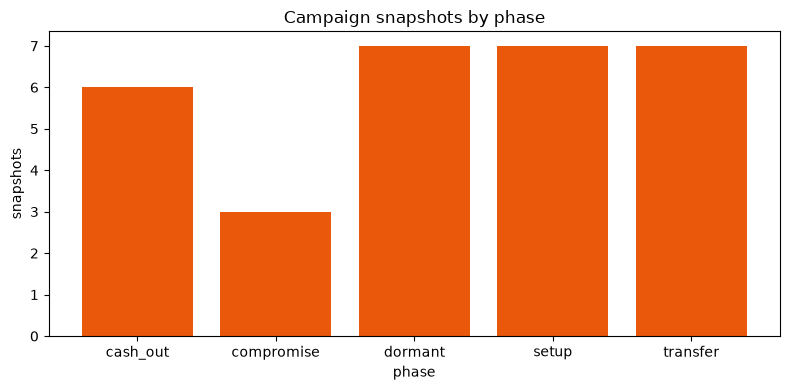

In [4]:
phases = Counter(x.phase for x in dynamic.snapshots)
try:
    import matplotlib.pyplot as plt

    phase_names = list(sorted(phases))
    fig, axis = plt.subplots(figsize=(8, 4))
    axis.bar(phase_names, [phases[name] for name in phase_names], color="#ea580c")
    axis.set(title="Campaign snapshots by phase", xlabel="phase", ylabel="snapshots")
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    print("Install matplotlib to render the campaign-phase plot.")
assert phases

In [5]:
transitions = [(x.campaign_id, x.from_phase, x.to_phase) for x in dynamic.transitions]
print("First campaign transitions:")
for campaign, from_phase, to_phase in transitions[:8]:
    print(f"  {campaign}: {from_phase} -> {to_phase}")
assert transitions

First campaign transitions:
  G-CYCLIC_RING-0002: compromise -> setup
  G-CYCLIC_RING-0002: setup -> transfer
  G-CYCLIC_RING-0002: transfer -> dormant
  G-CYCLIC_RING-0002: dormant -> setup
  G-CYCLIC_RING-0002: setup -> transfer
  G-CYCLIC_RING-0002: transfer -> cash_out
  G-CYCLIC_RING-0002: cash_out -> dormant
  G-CYCLIC_RING-0002: dormant -> closed


In [6]:
members = Counter(x.campaign_id for x in dynamic.membership_changes)
print({"membership_changes": dict(members)})
assert members

{'membership_changes': {'G-CYCLIC_RING-0002': 2, 'G-DENSE_CAMPAIGN-0003': 2, 'G-MULE_NETWORK-0001': 2}}


In [7]:
lineage = [
    {
        "campaign": x.campaign_id,
        "derived_events": len(x.derived_event_ids),
        "derived_payments": len(x.derived_payment_ids),
    }
    for x in dynamic.lineage
]
print("Campaign lineage:")
for item in lineage:
    print(
        f"  - {item['campaign']}: events={item['derived_events']}, "
        f"payments={item['derived_payments']}"
    )
assert all(x["derived_events"] >= 0 for x in lineage)

Campaign lineage:
  - G-CYCLIC_RING-0002: events=21, payments=6
  - G-DENSE_CAMPAIGN-0003: events=46, payments=15
  - G-MULE_NETWORK-0001: events=60, payments=19


In [8]:
times = [x.captured_at for x in dynamic.source_snapshots]
print(
    {
        "source_snapshots": len(times),
        "first": min(times).isoformat() if times else None,
        "last": max(times).isoformat() if times else None,
    }
)
assert len(times) == len(dynamic.source_snapshots)

{'source_snapshots': 3, 'first': '2026-01-01T00:10:00+00:00', 'last': '2026-01-01T00:15:00+00:00'}


In [9]:
manifest = {
    "run_id": data.run_id,
    "configuration_hash": dynamic.configuration_hash,
    "streams": dynamic.stream_ids,
    "campaigns": campaigns,
    "transitions": len(dynamic.transitions),
}
manifest["fingerprint"] = sha256_json(manifest)
print("Campaign manifest:")
print(f"  Run: {manifest['run_id']}")
print(f"  Configuration hash: {manifest['configuration_hash'][:12]}...")
print(f"  Streams: {len(manifest['streams'])}")
print(f"  Campaigns: {len(manifest['campaigns'])}")
print(f"  Transitions: {manifest['transitions']}")
print(f"  Fingerprint: {manifest['fingerprint']}")

Campaign manifest:
  Run: RUN-b80445cbde717564
  Configuration hash: 9c1206eb8d63...
  Streams: 9
  Campaigns: 3
  Transitions: 30
  Fingerprint: 0c0b84bb6eca3e57b5f5ac2d491dd498a227e85697f06960bde1c0695a0278e5


In [10]:
assert manifest["fingerprint"] == sha256_json(
    {k: v for k, v in manifest.items() if k != "fingerprint"}
)
print("Campaign state changes are linked to phases, actors, and source lineage.")

Campaign state changes are linked to phases, actors, and source lineage.


## Observable versus oracle investigation



In [11]:
from datetime import timedelta
from pathlib import Path

from fraudtwin.config import load_config
from fraudtwin.generation import generate
from fraudtwin.graph import build_graph
from fraudtwin.reproducibility import sha256_json

config = load_config(root / "configs" / "benchmarks" / "m11-graph-v2.yaml")
data = generate(config, write=False)
observable = build_graph(config, data.entities, data.behavior, data.manifest, view="observable")
oracle = build_graph(config, data.entities, data.behavior, data.manifest, view="oracle")
print(
    {
        "run_id": data.run_id,
        "observable_edges": len(observable.edges),
        "oracle_edges": len(oracle.edges),
    }
)
assert len(oracle.edges) >= len(observable.edges)

{'run_id': 'RUN-d4fe1230e312957d', 'observable_edges': 4191, 'oracle_edges': 4317}


In [12]:
print(
    {
        "nodes": {"observable": len(observable.nodes), "oracle": len(oracle.nodes)},
        "edges": {"observable": len(observable.edges), "oracle": len(oracle.edges)},
        "patterns": len(observable.patterns),
    }
)
assert len(oracle.nodes) >= len(observable.nodes)

{'nodes': {'observable': 417, 'oracle': 443}, 'edges': {'observable': 4191, 'oracle': 4317}, 'patterns': 899}


In [13]:
cutoff = config.simulation.start + timedelta(days=2)
observed_asof = build_graph(
    config, data.entities, data.behavior, data.manifest, view="observable", as_of=cutoff
)
oracle_asof = build_graph(
    config, data.entities, data.behavior, data.manifest, view="oracle", as_of=cutoff
)
print(
    {
        "cutoff": cutoff.isoformat(),
        "observed_edges": len(observed_asof.edges),
        "oracle_edges": len(oracle_asof.edges),
    }
)
assert len(observed_asof.edges) <= len(observable.edges)

{'cutoff': '2026-01-03T00:00:00+00:00', 'observed_edges': 1734, 'oracle_edges': 4317}


In [14]:
available = [
    edge
    for edge in observed_asof.edges
    if edge.available_at is not None and edge.available_at <= cutoff
]
print(
    {"available_by_cutoff": len(available), "excluded": len(observed_asof.edges) - len(available)}
)
assert len(available) <= len(observed_asof.edges)

{'available_by_cutoff': 1354, 'excluded': 380}


In [15]:
oracle_only = len(oracle_asof.edges) - len(observed_asof.edges)
print({"oracle_only_edges": oracle_only, "meaning": "latent truth is not investigator-visible"})
assert oracle_only >= 0

{'oracle_only_edges': 2583, 'meaning': 'latent truth is not investigator-visible'}


In [16]:
print([pattern.pattern_type for pattern in observable.patterns[:5]])
print({"observable_patterns": len(observable.patterns)})

['FAN_OUT', 'SHARED_IP_INFRASTRUCTURE', 'SHARED_DEVICE_INFRASTRUCTURE', 'SHARED_DEVICE_INFRASTRUCTURE', 'CYCLIC_RING']
{'observable_patterns': 899}


In [17]:
campaign_types = {}
for campaign in observable.campaigns:
    campaign_types[campaign.scenario_type] = campaign_types.get(campaign.scenario_type, 0) + 1
print(campaign_types)
assert isinstance(campaign_types, dict)

{}


In [18]:
post_cutoff = [
    edge for edge in observed_asof.edges if edge.event_time is not None and edge.event_time > cutoff
]
print({"post_cutoff_edges": len(post_cutoff)})
assert not post_cutoff

{'post_cutoff_edges': 0}


In [19]:
manifest = {
    "run_id": data.run_id,
    "cutoff": cutoff.isoformat(),
    "observable_edges": len(observable.edges),
    "oracle_edges": len(oracle.edges),
    "oracle_only_at_cutoff": oracle_only,
}
manifest["fingerprint"] = sha256_json(manifest)
print("Graph manifest:")
print(f"  Run: {manifest['run_id']}")
print(f"  Cutoff: {manifest['cutoff']}")
print(f"  Observable edges: {manifest['observable_edges']:,}")
print(f"  Oracle edges: {manifest['oracle_edges']:,}")
print(f"  Oracle-only edges at cutoff: {manifest['oracle_only_at_cutoff']:,}")
print(f"  Fingerprint: {manifest['fingerprint']}")

Graph manifest:
  Run: RUN-d4fe1230e312957d
  Cutoff: 2026-01-03T00:00:00+00:00
  Observable edges: 4,191
  Oracle edges: 4,317
  Oracle-only edges at cutoff: 2,583
  Fingerprint: b5c915bedd09b25d1dd671210aac6f8640ed444f58ef0f7f90ae155630543c0d


In [20]:
assert manifest["fingerprint"] == sha256_json(
    {k: v for k, v in manifest.items() if k != "fingerprint"}
)
print(
    "Observable graphs support leakage-safe investigation; oracle graphs explain benchmark truth."
)

Observable graphs support leakage-safe investigation; oracle graphs explain benchmark truth.


## Verification and next step

Re-run the offline cells from a clean checkout and compare the printed fingerprints. For service-backed publication, continue with the relevant integration runbook after this notebook; do not treat synthetic metrics as a deployment SLO.
